# LangGraph Mini Tour

This notebook builds four small LangGraph examples using Pydantic models to structure state.

In [39]:
# Core imports shared by all examples
from __future__ import annotations

from typing import Any, List

from IPython.display import Image, display
from langgraph.graph import StateGraph, END , START
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from openinference.instrumentation.langchain import LangChainInstrumentor
from typing_extensions import Optional, Annotated, List, Sequence

from opentelemetry import trace

import rich
from langgraph.graph.message import add_messages

import operator


In [2]:
import dotenv
import os

In [3]:
dotenv.load_dotenv("../env_workshop")

True

In [4]:
OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL")


In [5]:
PHOENIX_PROJECT_NAME=os.environ.get("PHOENIX_PROJECT_NAME")

In [26]:
from phoenix.otel import register
from openinference.instrumentation import using_metadata

# configure the Phoenix tracer
tracer_provider = register(
  project_name=PHOENIX_PROJECT_NAME, 
  auto_instrument=False 
)
LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

tracer = trace.get_tracer(__name__)


Overriding of current TracerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



Attempting to instrument while already instrumented


## Graph 1: Simple Math example
A minimal graph with one node that sums two numbers.

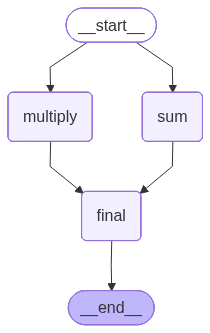

In [27]:
class MathState(BaseModel):
    a: int
    b: int
    total_sum: int | None = None
    total_multiply: int | None = None
    total_final: int | None = None


def compute_sum(state: MathState) -> dict[str, Any]:
    return {"total_sum": state.a + state.b}

def compute_product(state: MathState) -> dict[str, Any]:
    return {"total_multiply": state.a * state.b}

def compute_final(state: MathState) -> dict[str, Any]:
    return {"total_final": state.total_sum + state.total_multiply}

single_node_graph = StateGraph(MathState)
single_node_graph.add_node("sum", compute_sum)
single_node_graph.add_node("multiply", compute_product)
single_node_graph.add_node("final", compute_final)
single_node_graph.add_edge(START, "sum")
single_node_graph.add_edge(START, "multiply")

single_node_graph.add_edge("sum", "final")
single_node_graph.add_edge("multiply", "final")
single_node_graph.add_edge("final", END)

single_node_app = single_node_graph.compile()
display(Image(single_node_app.get_graph().draw_mermaid_png()))


with tracer.start_as_current_span("simple_math_example"):
    single_node_app.invoke(MathState(a=2, b=5))

## Tool Calling

In [9]:
model = ChatOpenAI(
    model="gpt-4o-mini",
    base_url=OPENAI_BASE_URL,
    #temperature=0.2,
    #max_tokens=512,
)

In [ ]:
@tool
def animal_joke(animal: str) -> str:
    """Return a short, clean joke for turtle/cat/dog (falls back to dog)."""

    JOKES = {
    "turtle": "Why don’t turtles use public Wi-Fi? Too many shell networks.",
    "cat":    "Why did the cat sit on the computer? To keep an eye on the mouse.",
    "dog":    "What do you call a dog that does magic? A labracadabrador.",
    }
    return JOKES.get((animal or "").lower().strip(), JOKES["dog"])

tool_model = model.bind_tools([animal_joke])  # for tool calling


# ---- Build messages explicitly (System + Human) ----
animal = "turtle"
messages = [
    SystemMessage(content="You are a concise jokester."),
    HumanMessage(content=f"Tell me a short, clean joke about {animal}."),
]




In [29]:
with tracer.start_as_current_span("tool_calling_example"):
    
    ai_msg = tool_model.invoke(
        messages
    )
    
    print(f"Message generated from our llm call")
    rich.print(ai_msg)


    # get tool call and arguments
    tc = ai_msg.tool_calls[0]         
    
    # invoke tool call
    tool_result = animal_joke.invoke(tc["args"] )

    # tool output result
    print(f"tool output result")
    rich.print(tool_result)

Message generated from our llm call


AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 17,
            'prompt_tokens': 73,
            'total_tokens': 90,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'gpt-4o-mini-2024-07-18',
        'system_fingerprint': 'fp_560af6e559',
        'id': 'chatcmpl-CT1i4R9tmhflwnKEG1JIP2KlENmRa',
        'service_tier': 'default',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--dd6c2471-6bda-40e9-8450-d4c4d1647cba-0',
    tool_calls=[
        {
            'name': 'animal_joke',
            'args': {'animal': 'turtle'},
            'id': 'call_Flg0BzoFbM8JkEDRfcR4icaz',
            'type': 'tool_call'
        }
    ],
    usage_metadata={
        'input_tokens': 73,
        'output_tokens': 17,
        'total_tokens': 90,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

tool output result


Why don’t turtles use public Wi-Fi? Too many shell networks.

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 17,
            'prompt_tokens': 73,
            'total_tokens': 90,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'gpt-4o-mini-2024-07-18',
        'system_fingerprint': 'fp_560af6e559',
        'id': 'chatcmpl-CT1i4R9tmhflwnKEG1JIP2KlENmRa',
        'service_tier': 'default',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--9d7f4cad-a391-45dd-b4e6-4850365d8950-0',
    tool_calls=[
        {
            'name': 'animal_joke',
            'args': {'animal': 'turtle'},
            'id': 'call_Flg0BzoFbM8JkEDRfcR4icaz',
            'type': 'tool_call'
        }
    ],
    usage_metadata={
        'input_tokens': 73,
        'output_tokens': 17,
        'total_tokens': 90,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

Why don’t turtles use public Wi-Fi? Too many shell networks.

## Structured Outputs

In [30]:
class AnimalInfo(BaseModel):
    name:str
    first_discovered:str
    latin_name: str
    num_species:str

In [14]:
model_with_structured_output = model.with_structured_output(AnimalInfo)


## Simpe Research Flow
Takes an initial query, generates follow-up prompts, fabricates findings, then aggregates them.

In [54]:
class ResearchState(BaseModel):
    query: str
    sub_queries: List[str] = Field(default_factory=list)
    raw_notes: Annotated[list[str], operator.add] = []
    final_report: str = None

def expand_queries(state: ResearchState) -> dict[str, Any]:
    suggestions = [
        f"{state.query} overview",
        f"{state.query} challenges",
        f"{state.query} opportunities",
    ]
    return {"sub_queries": suggestions}

def gather_research(state: ResearchState) -> dict[str, Any]:
    raw_notes = [f"Research for '{item}': placeholder insight." for item in state.sub_queries]
    return {"raw_notes": raw_notes}

def summarize_research(state: ResearchState) -> dict[str, Any]:
    summaries = [f"Summary {idx + 1}: {finding}" for idx, finding in enumerate(state.raw_notes)]
    
    research_report = f"""
    # Introdfuction

    user queried about : {state.query}

    # Findings
    {state.raw_notes}

    # Conclusion
    {state.final_report}


    """
    
    return {"final_report": research_report}



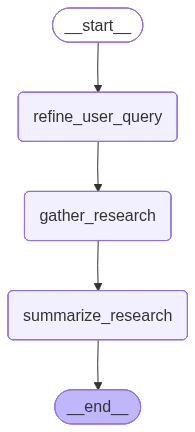

In [55]:
research_graph = StateGraph(ResearchState)
research_graph.add_node("refine_user_query", expand_queries)
research_graph.add_node("gather_research", gather_research)
research_graph.add_node("summarize_research", summarize_research)
research_graph.set_entry_point("refine_user_query")
research_graph.add_edge("refine_user_query", "gather_research")
research_graph.add_edge("gather_research", "summarize_research")
research_graph.add_edge("summarize_research", END)
research_app = research_graph.compile()
display(Image(research_app.get_graph().draw_mermaid_png()))



In [58]:
research_app.invoke(ResearchState(query="AI Agents"))



{'query': 'AI Agents',
 'sub_queries': ['AI Agents overview',
  'AI Agents challenges',
  'AI Agents opportunities'],
 'raw_notes': ["Research for 'AI Agents overview': placeholder insight.",
  "Research for 'AI Agents challenges': placeholder insight.",
  "Research for 'AI Agents opportunities': placeholder insight."],
 'final_report': '\n    # Introdfuction\n\n    user queried about : AI Agents\n\n    # Findings\n    ["Research for \'AI Agents overview\': placeholder insight.", "Research for \'AI Agents challenges\': placeholder insight.", "Research for \'AI Agents opportunities\': placeholder insight."]\n\n    # Conclusion\n    None\n\n\n    '}